# Ocean Lake sample 18S-seq (paired-end) QIIME 2 Analysis

#### by Jingjing Cheng and Xiangpeng Li

## Goal
QIIME 2 analysis: 18S-seq paired-end reads.

## Raw data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_18S_rename/`
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_18S_analysis`

# Generate manifest.tsv (paired-end)

QIIME 2 paired-end import requires a manifest with:
- sample-id
- forward-absolute-filepath
- reverse-absolute-filepath

We generate the manifest and save the file in `/data10/xli/project/pama-seq/OL_18S_analysis/`.

In [3]:
# Generate manifest.tsv (paired-end)
import os
import re

# Input and output paths
input_dir = "/data10/xli/raw_data/miseq_202512_jingjing/OL_18S_rename"
output_manifest = "/data10/xli/project/pama-seq/OL_18S_analysis/manifest.tsv"

# Regex to extract sample ID
pattern = re.compile(r"(.+)_S\d+_L001_R1_001.fastq.gz")

# Collect R1 files
r1_files = [f for f in os.listdir(input_dir) if f.endswith("_R1_001.fastq.gz")]

with open(output_manifest, "w") as out:
    # Write header
    out.write("sample-id\tforward-absolute-filepath\treverse-absolute-filepath\n")
    
    for r1 in sorted(r1_files):
        match = pattern.match(r1)
        if not match:
            continue
        
        sample_id = match.group(1)
        
        r1_path = os.path.abspath(os.path.join(input_dir, r1))
        r2 = r1.replace("_R1_", "_R2_")
        r2_path = os.path.abspath(os.path.join(input_dir, r2))
        
        if not os.path.exists(r2_path):
            print(f"Warning: Missing R2 file for {sample_id}")
            continue
        
        out.write(f"{sample_id}\t{r1_path}\t{r2_path}\n")

print(f"Manifest saved to: {output_manifest}")

Manifest saved to: /data10/xli/project/pama-seq/OL_18S_analysis/manifest.tsv


## Run Qiime2 for analysis 

cd  /data10/xli/project/pama-seq/OL_18S_analysis/
conda activate qiime2-amplicon-2025.7

qiime tools import \
  --type 'SampleData[PairedEndSequencesWithQuality]' \
  --input-path manifest.tsv \
  --output-path demux-paired.qza \
  --input-format PairedEndFastqManifestPhred33V2

qiime demux summarize \
  --i-data demux-paired.qza \
  --o-visualization demux-paired.qzv

## Demultiplexed read quality assessment (demux summarize)

After importing the paired-end PAMA-seq reads into QIIME 2, we summarize the
demultiplexed data to assess sequencing quality before denoising.

## DADA2 denoising and paired-end merging

After assessing read quality with `demux summarize`, we perform denoising and
paired-end merging using **DADA2**.

### Purpose
This step aims to:
- Correct sequencing errors using a learned error model
- Infer exact amplicon sequence variants (ASVs)
- Merge forward and reverse reads
- Remove chimeric sequences
- Generate a feature table and representative sequences

### Parameter choice
Truncation lengths were selected based on the quality profiles observed in
`demux-paired.qzv`:

- Forward reads (R1): truncated at **100 bp**
- Reverse reads (R2): truncated at **100 bp**

No primer or barcode trimming is applied (`trim-left = 0`) because these
sequences were already removed upstream.

### Execution strategy
DADA2 is computationally intensive.  
To avoid interruption due to network or SSH disconnection, the command is
executed as a **background batch job**.

save the following as "/data10/xli/project/pama-seq/OL_16S_analysis/qiime2_18s.sh"
and run the following command:
bash qiime2_18s.sh

In [1]:
!ls  /data10/xli/project/pama-seq/OL_18S_analysis/*

/data10/xli/project/pama-seq/OL_18S_analysis/demux-paired.qza
/data10/xli/project/pama-seq/OL_18S_analysis/demux-paired.qzv
/data10/xli/project/pama-seq/OL_18S_analysis/denoising-stats.qza
/data10/xli/project/pama-seq/OL_18S_analysis/manifest.tsv
/data10/xli/project/pama-seq/OL_18S_analysis/qiime2_18s.sh
/data10/xli/project/pama-seq/OL_18S_analysis/rep-seqs.qza
/data10/xli/project/pama-seq/OL_18S_analysis/table.qza
/data10/xli/project/pama-seq/OL_18S_analysis/taxonomy.qza
/data10/xli/project/pama-seq/OL_18S_analysis/taxonomy.qzv

/data10/xli/project/pama-seq/OL_18S_analysis/exported-feature-table:
feature-table.biom  feature_table.tsv

/data10/xli/project/pama-seq/OL_18S_analysis/exported-taxonomy:
taxonomy.tsv


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [13]:
# Load taxonomy and ASV feature tables from working directory and perform initial data integrity check

# ==============================
# 1. Working directory (18S trim100)
# ==============================
wk_dir = "/data10/xli/project/pama-seq/OL_18S_analysis/"

# ==============================
# 2. Load taxonomy table
# ==============================
taxonomy_file = os.path.join(
    wk_dir,
    "exported-taxonomy/taxonomy.tsv"
)

tax = pd.read_csv(taxonomy_file, sep="\t")

# ==============================
# 3. Load ASV feature table
# ==============================
table_file = os.path.join(
    wk_dir,
    "exported-feature-table/feature_table.tsv"
)

ft = pd.read_csv(
    table_file,
    sep="\t",
    skiprows=1,
    index_col=0
)

# ==============================
# 4. Quick sanity check
# ==============================
print("Taxonomy:")
display(tax.head())

print("\nASV table:")
display(ft.iloc[:5, :])



Taxonomy:


,Feature ID,Taxon,Confidence
0,580f28aa5d1f44a43a6dfff991ec40d1,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.966526
1,00d87d56475b26569d129f896e82aa2a,d__Eukaryota,0.998759
2,b443bc86139d20e266f08bcf24cf751a,d__Eukaryota;p__Arthropoda,0.783463
3,4f979d7eedec737a4aaafc26652f6bf2,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__C...,0.761197
4,0f3cd48f1c94814b7154f25164019d34,d__Eukaryota;p__Chlorophyta,0.988372



ASV table:


,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b
#OTU ID,,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0
00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0
b443bc86139d20e266f08bcf24cf751a,18097.0,17432.0,6233.0,7004.0,0.0,0.0,0.0,0.0
4f979d7eedec737a4aaafc26652f6bf2,2507.0,2575.0,0.0,0.0,5078.0,7931.0,10777.0,12323.0
0f3cd48f1c94814b7154f25164019d34,6552.0,6662.0,4939.0,6188.0,370.0,709.0,986.0,1224.0


In [40]:
# =========================
# Output
# =========================
out_dir = wk_dir +'output/'
os.makedirs(out_dir, exist_ok=True)


In [41]:
# Subset taxonomy columns and filter features with confidence ≥ 0.90 for downstream analysis

tax_qiime = tax[["Feature ID", "Taxon", "Confidence"]].copy()
tax_qiime = tax_qiime[tax_qiime["Confidence"] >= 0.90]
tax_qiime.columns = ["Feature ID", "Taxon", "Confidence"]
tax_qiime.head()

,Feature ID,Taxon,Confidence
0,580f28aa5d1f44a43a6dfff991ec40d1,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.966526
1,00d87d56475b26569d129f896e82aa2a,d__Eukaryota,0.998759
4,0f3cd48f1c94814b7154f25164019d34,d__Eukaryota;p__Chlorophyta,0.988372
5,11b9d90019b1ad2132d54d18269e8cfe,d__Eukaryota;p__Diatomea,0.956007
6,4f4c9cb45479dbc207642b01c955e0fa,d__Eukaryota,0.998695


In [42]:
ft

,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b
Feature ID,,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0
00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0
b443bc86139d20e266f08bcf24cf751a,18097.0,17432.0,6233.0,7004.0,0.0,0.0,0.0,0.0
4f979d7eedec737a4aaafc26652f6bf2,2507.0,2575.0,0.0,0.0,5078.0,7931.0,10777.0,12323.0
0f3cd48f1c94814b7154f25164019d34,6552.0,6662.0,4939.0,6188.0,370.0,709.0,986.0,1224.0
...,...,...,...,...,...,...,...,...
35e37681ca61137ca2ac9e3e73249c48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
b852c98172054acb0d8f7505935cb19a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2185cc2e7aef46ccc483571518e2f64d,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [43]:
# Set feature table index to Feature ID to align with taxonomy table structure

ft.index.name = "Feature ID"
ft.head()

,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b
Feature ID,,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0
00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0
b443bc86139d20e266f08bcf24cf751a,18097.0,17432.0,6233.0,7004.0,0.0,0.0,0.0,0.0
4f979d7eedec737a4aaafc26652f6bf2,2507.0,2575.0,0.0,0.0,5078.0,7931.0,10777.0,12323.0
0f3cd48f1c94814b7154f25164019d34,6552.0,6662.0,4939.0,6188.0,370.0,709.0,986.0,1224.0


In [44]:
# Reload feature table to verify column names and sample labeling consistency

import pandas as pd
ft_check = pd.read_csv(
    "/data10/jingjing/project/pama_seq_qiime2/OL_18S_trim100/table_18S_100_100.tsv",
    sep="\t",
    skiprows=1
)
print(ft_check.columns.tolist())
print(ft_check.iloc[0, :5])

['#OTU ID', 'Ocean-lake-1a', 'Ocean-lake-1b', 'Ocean-lake-2a', 'Ocean-lake-2b', 'Ocean-lake-3a', 'Ocean-lake-3b', 'Ocean-lake-4a', 'Ocean-lake-4b']
#OTU ID          580f28aa5d1f44a43a6dfff991ec40d1
Ocean-lake-1a                             58856.0
Ocean-lake-1b                             59122.0
Ocean-lake-2a                             68237.0
Ocean-lake-2b                             78652.0
Name: 0, dtype: object


In [45]:
# Merge taxonomy with ASV counts, remove all-zero features, and retain features with confidence ≥ 0.90

tax_clean = tax_qiime.copy()

# 1) Make both tables use Feature ID as index
meta_df = tax_clean.set_index("Feature ID")[["Taxon", "Confidence"]]

# 2) feature_table: ft must use Feature ID as index
taxon_df = ft.copy()
taxon_df.index.name = "Feature ID"

# 3) Join taxonomy onto counts
ol_df_with_taxon = taxon_df.join(meta_df, how="left")

# 4) Remove all-zero features
sample_cols = taxon_df.columns
ol_df_clean = ol_df_with_taxon.loc[(ol_df_with_taxon[sample_cols] != 0).any(axis=1)].copy()

conf_thresh = 0.90

ol_df_clean = ol_df_clean.loc[
    ol_df_clean["Confidence"] >= conf_thresh
].copy()

ol_df_clean.head()

,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b,Taxon,Confidence
Feature ID,,,,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.966526
00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0,d__Eukaryota,0.998759
0f3cd48f1c94814b7154f25164019d34,6552.0,6662.0,4939.0,6188.0,370.0,709.0,986.0,1224.0,d__Eukaryota;p__Chlorophyta,0.988372
11b9d90019b1ad2132d54d18269e8cfe,59.0,59.0,42.0,43.0,2888.0,4531.0,5830.0,7120.0,d__Eukaryota;p__Diatomea,0.956007
4f4c9cb45479dbc207642b01c955e0fa,0.0,0.0,0.0,0.0,4906.0,7588.0,3741.0,3220.0,d__Eukaryota,0.998695


In [46]:
# Parse taxonomy strings into standardized rank columns (Kingdom–Species) with 
# cleaned labels and missing values normalized to NaN

import numpy as np
import pandas as pd

# 1) Split the taxonomy string into rank levels (Kingdom ... Species)
taxon_levels = ol_df_clean["Taxon"].astype(str).str.split(";", expand=True)

# 2) Ensure we always have exactly 7 columns (pad with NaN if taxonomy is shorter)
taxon_levels = taxon_levels.reindex(columns=range(7))

# 3) Name the columns by taxonomic rank
taxon_levels.columns = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# 4) Clean formatting: trim spaces and remove prefixes like k__, p__, c__, etc.
taxon_levels = taxon_levels.apply(
    lambda s: (
        s.astype("string")
         .str.strip()
         .str.replace(r"^[a-z]__", "", regex=True)  # remove leading rank prefix
    )
)

# 5) Standardize missing/unknown labels to NaN (optional but recommended)
taxon_levels = taxon_levels.replace({"": np.nan, "None": np.nan, "nan": np.nan, "Unassigned": np.nan})

taxon_levels.head()

,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,<NA>
00d87d56475b26569d129f896e82aa2a,Eukaryota,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
0f3cd48f1c94814b7154f25164019d34,Eukaryota,Chlorophyta,<NA>,<NA>,<NA>,<NA>,<NA>
11b9d90019b1ad2132d54d18269e8cfe,Eukaryota,Diatomea,<NA>,<NA>,<NA>,<NA>,<NA>
4f4c9cb45479dbc207642b01c955e0fa,Eukaryota,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [47]:
# Merge count table with taxonomy ranks, standardize missing labels as 'Unassigned', 
# and filter out Chloroplast/Mitochondria across all ranks

# 1) Combine ASV count table with parsed taxonomy levels
ol_df_final = pd.concat([ol_df_clean, taxon_levels], axis=1)

# 2) Define taxonomy columns
tax_cols = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# 3) Fill missing taxonomy labels as 'Unassigned'
ol_df_final[tax_cols] = ol_df_final[tax_cols].fillna("Unassigned")

# 3.5) Remove Chloroplast and Mitochondria across all taxonomy levels
tax_levels = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

mask = ~(
    ol_df_final[tax_levels]
    .apply(lambda col: col.str.contains("Chloroplast|Mitochondria", case=False, na=False))
    .any(axis=1)
)

ol_df_final = ol_df_final[mask]
print(f"Rows after removing Chloroplast & Mitochondria: {len(ol_df_final)}")

# 4) Quick check
ol_df_final.head()

Rows after removing Chloroplast & Mitochondria: 2138


,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b,Taxon,Confidence,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,,,,,,,,,,,
580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.966526,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned
00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0,d__Eukaryota,0.998759,Eukaryota,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
0f3cd48f1c94814b7154f25164019d34,6552.0,6662.0,4939.0,6188.0,370.0,709.0,986.0,1224.0,d__Eukaryota;p__Chlorophyta,0.988372,Eukaryota,Chlorophyta,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
11b9d90019b1ad2132d54d18269e8cfe,59.0,59.0,42.0,43.0,2888.0,4531.0,5830.0,7120.0,d__Eukaryota;p__Diatomea,0.956007,Eukaryota,Diatomea,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned
4f4c9cb45479dbc207642b01c955e0fa,0.0,0.0,0.0,0.0,4906.0,7588.0,3741.0,3220.0,d__Eukaryota,0.998695,Eukaryota,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned


In [48]:
# Convert merged ASV table to long format, define sample-wise counts, 
# and remove zero counts and genus-level 'Unassigned' entries


# Final step: convert wide ASV table to long format (for plotting)
df0 = ol_df_final.reset_index()

# ensure Feature ID column name is correct
df0 = df0.rename(columns={df0.columns[0]: "Feature ID"})

# identify sample columns (numeric count columns)
sample_cols = df0.select_dtypes(include="number").columns.tolist()
if "Confidence" in sample_cols:
    sample_cols.remove("Confidence")

tax_cols = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

long_df = df0.melt(
    id_vars=["Feature ID"] + tax_cols,
    value_vars=sample_cols,
    var_name="SampleID",
    value_name="Count"
)

# remove zero counts
long_df = long_df[long_df["Count"] > 0].copy()
# Remove genus-level Unassigned BEFORE relative abundance
long_df = long_df.loc[long_df["Genus"] != "Unassigned"].copy()

long_df.head()

,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count
0,580f28aa5d1f44a43a6dfff991ec40d1,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,58850.0
15,b0c5b9aafe4462cc72c6e96c60040d26,Eukaryota,Mollusca,Bivalvia,Veneroida,Veneroida,Veneroida,Unassigned,Ocean-lake-1a,2176.0
18,5cf8c03e23441ef96ea64d4f8b542ff3,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,2293.0
23,72baa20d784fde5d3dcb25d911c2e21b,Eukaryota,Ciliophora,Intramacronucleata,Litostomatea,Mesodiniidae,Myrionecta,Unassigned,Ocean-lake-1a,2156.0
44,2fbc153fb7151998bd7a89612af7c275,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,11.0


In [49]:
# Sum counts per SampleID × Genus
genus_table_18s = (
    long_df
    .groupby(["SampleID", "Genus"], as_index=False)["Count"]
    .sum()
)

# Convert to relative abundance within each sample
genus_table_18s["RelAbundance"] = (
    genus_table_18s["Count"]
    / genus_table_18s.groupby("SampleID")["Count"].transform("sum")
)

# Pivot to Genus × Sample matrix
genus_matrix_18s = genus_table_18s.pivot(
    index="Genus",
    columns="SampleID",
    values="RelAbundance"
).fillna(0)

# Quick sanity check
genus_matrix_18s.sum()

SampleID
Ocean-lake-1a    1.0
Ocean-lake-1b    1.0
Ocean-lake-2a    1.0
Ocean-lake-2b    1.0
Ocean-lake-3a    1.0
Ocean-lake-3b    1.0
Ocean-lake-4a    1.0
Ocean-lake-4b    1.0
dtype: float64

In [50]:
# Step 1 (18S): detect 18S replicate pairs (a,b)

samples_18s = sorted([s for s in genus_matrix_18s.columns if s.startswith("Ocean-lake-")])

indices = sorted(set([s.split("Ocean-lake-")[-1][:-1] for s in samples_18s]))  # e.g., "1","2","3"
pairs_18s = []
for i in indices:
    a = f"Ocean-lake-{i}a"
    b = f"Ocean-lake-{i}b"
    if (a in genus_matrix_18s.columns) and (b in genus_matrix_18s.columns):
        pairs_18s.append((a, b))

print("Detected pairs (18S):", pairs_18s)

Detected pairs (18S): [('Ocean-lake-1a', 'Ocean-lake-1b'), ('Ocean-lake-2a', 'Ocean-lake-2b'), ('Ocean-lake-3a', 'Ocean-lake-3b'), ('Ocean-lake-4a', 'Ocean-lake-4b')]


In [51]:
# Step 2 (18S): focus on ONE sample (Ocean-lake-1a vs 1b)

sample_a, sample_b = pairs_18s[0]   # first 18S sample pair

x = genus_matrix_18s[sample_a]
y = genus_matrix_18s[sample_b]

mask = (x > 0) | (y > 0)

print("Total genera in full matrix:", len(x))
print("Genera present in this sample:", mask.sum())

Total genera in full matrix: 153
Genera present in this sample: 35


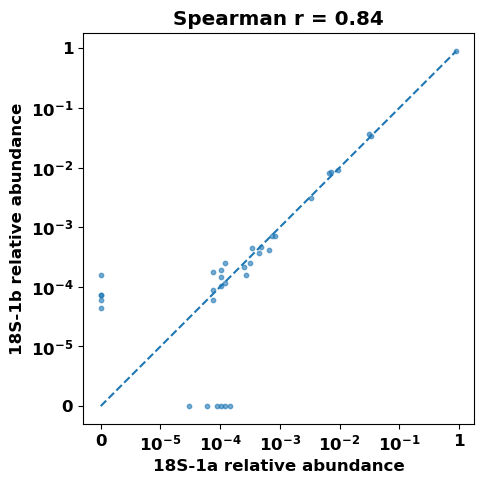

Filtered genera used: 35
Spearman r (filtered): 0.8417828558332818


In [52]:
# Step 3 (18S): compute correlation + plot using ONLY genera present in this sample

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pseudo = 1e-6

# 1) apply mask
x_sub = x[mask]
y_sub = y[mask]

# 2) Spearman correlation
rho, _ = spearmanr(x_sub, y_sub)

# 3) log10 for plotting
x_log = np.log10(x_sub + pseudo)
y_log = np.log10(y_sub + pseudo)

plt.figure(figsize=(5, 5))
plt.scatter(x_log, y_log, s=10, alpha=0.6)

min_val = min(x_log.min(), y_log.min())
max_val = max(x_log.max(), y_log.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ticks = [-6, -5, -4, -3, -2, -1, 0]
labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$",
          r"$10^{-2}$", r"$10^{-1}$", "1"]
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

label_a = sample_a.replace("Ocean-lake-", "18S-")
label_b = sample_b.replace("Ocean-lake-", "18S-")

plt.xlabel(f"{label_a} relative abundance")
plt.ylabel(f"{label_b} relative abundance")
plt.title(f"Spearman r = {rho:.2f}")

plt.tight_layout()
plt.show()

print("Filtered genera used:", len(x_sub))
print("Spearman r (filtered):", rho)

In [53]:
import matplotlib.pyplot as plt
print("font.size =", plt.rcParams["font.size"])
print("font.family =", plt.rcParams["font.family"])
print("pdf.fonttype =", plt.rcParams["pdf.fonttype"])

font.size = 12.0
font.family = ['sans-serif']
pdf.fonttype = 42


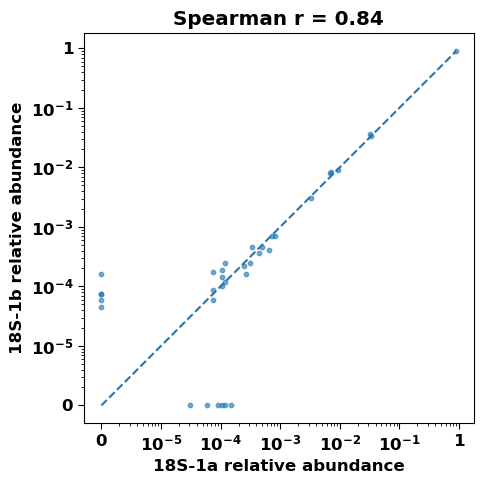

Ocean-lake-1a vs Ocean-lake-1b | genera used: 35 | Spearman r: 0.842


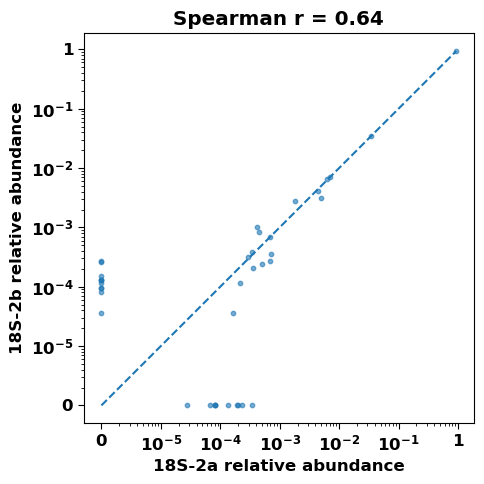

Ocean-lake-2a vs Ocean-lake-2b | genera used: 39 | Spearman r: 0.636


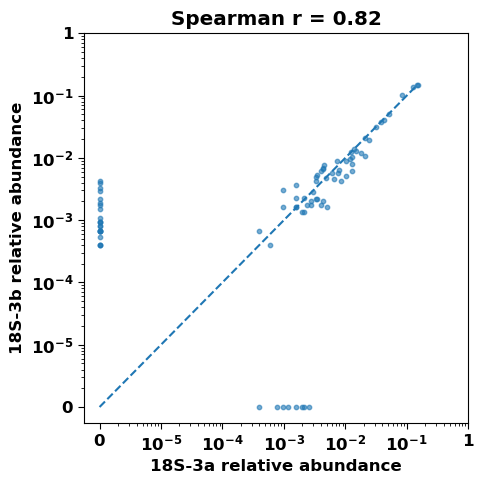

Ocean-lake-3a vs Ocean-lake-3b | genera used: 86 | Spearman r: 0.815


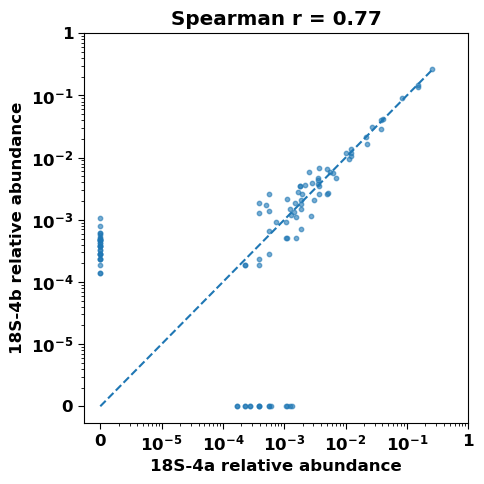

Ocean-lake-4a vs Ocean-lake-4b | genera used: 108 | Spearman r: 0.771


In [54]:
pseudo = 1e-6

# =========================
# Global style (safe on Linux/HPC)
# =========================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["pdf.fonttype"] = 42   # editable text in Illustrator
plt.rcParams["ps.fonttype"] = 42

# Make fonts bold-ish (optional)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Font sizes (edit here)
FS_TITLE = 16
FS_AXLABEL = 16
FS_TICK = 12
FS_LEGEND = 11
FS_LEGEND_TITLE = 12


# ---- ADD: log-style minor ticks for log10-transformed axes ----
import numpy as np
import matplotlib.ticker as ticker

def add_log10_minor_ticks(ax, major_ticks):
    """
    major_ticks: e.g. [-6, -5, -4, -3, -2, -1, 0]
    Adds minor ticks at k + log10(2..9) for each interval [k, k+1].
    Use when your plotted values are already log10-transformed (linear axis).
    """
    subs = np.log10(np.arange(2, 10))  # log10(2..9)
    minor = []
    for k in major_ticks[:-1]:
        minor.extend(list(k + subs))

    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))

    # show tick marks only (no labels)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    # keep major labels as-is; just add minor "bars"
    ax.tick_params(which="major", length=4, width=0.8, direction="out")
    ax.tick_params(which="minor", length=2, width=0.6, direction="out")


for sample_a, sample_b in pairs_18s:

    x = genus_matrix_18s[sample_a]
    y = genus_matrix_18s[sample_b]

    # sample-specific genus space
    mask = (x > 0) | (y > 0)

    x_sub = x[mask]
    y_sub = y[mask]

    rho, _ = spearmanr(x_sub, y_sub)

    x_log = np.log10(x_sub + pseudo)
    y_log = np.log10(y_sub + pseudo)

    plt.figure(figsize=(5, 5))
    plt.scatter(x_log, y_log, s=10, alpha=0.6)

    min_val = min(x_log.min(), y_log.min())
    max_val = max(x_log.max(), y_log.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ticks = [-6, -5, -4, -3, -2, -1, 0]
    labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$",
              r"$10^{-2}$", r"$10^{-1}$", "1"]
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)

    # ---- ADD THIS LINE: minor tick "one-bar-one-bar" ----
    ax = plt.gca()
    add_log10_minor_ticks(ax, ticks)

    label_a = sample_a.replace("Ocean-lake-", "18S-")
    label_b = sample_b.replace("Ocean-lake-", "18S-")

    plt.xlabel(f"{label_a} relative abundance")
    plt.ylabel(f"{label_b} relative abundance")
    plt.title(f"Spearman r = {rho:.2f}")

    plt.tight_layout()
    plt.savefig(out_dir + f"{sample_a}_vs_{sample_b}_shared_genus.pdf",
                bbox_inches="tight")
    plt.show()

    print(sample_a, "vs", sample_b,
          "| genera used:", len(x_sub),
          "| Spearman r:", round(rho, 3))

In [55]:
# Aggregate counts at the selected taxonomic rank and calculate within-sample relative abundance

rank = "Phylum"   # change to "Class", "Order", "Family", "Genus", "Species" anytime

rank_ab = (
    long_df.groupby(["SampleID", rank], as_index=False)["Count"]
    .sum()
)

rank_ab["RelAbundance"] = rank_ab["Count"] / rank_ab.groupby("SampleID")["Count"].transform("sum")
rank_ab.head()

,SampleID,Phylum,Count,RelAbundance
0,Ocean-lake-1a,Amoebozoa,7.0,0.000103
1,Ocean-lake-1a,Annelida,8.0,0.000118
2,Ocean-lake-1a,Arthropoda,5.0,0.000074
3,Ocean-lake-1a,Ascomycota,8.0,0.000118
4,Ocean-lake-1a,Bdellovibrionota,7.0,0.000103


In [56]:
# Pivot relative abundance table to wide format (samples × taxa) for multivariate analysis

plot_wide = rank_ab.pivot_table(
    index="SampleID",
    columns=rank,
    values="RelAbundance",
    fill_value=0
)

plot_wide.head()

Phylum,Acidobacteriota,Amoebozoa,Ancyromonadida,Annelida,Apicomplexa,Apusomonadidae,Arthropoda,Ascomycota,Bdellovibrionota,Bicosoecida,...,Picozoa,Planctomycetota,Protalveolata,Proteobacteria,Prymnesiophyceae,Retaria,Rigifilida,SA1-3C06,SAR,Verrucomicrobiota
SampleID,,,,,,,,,,,,,,,,,,,,,
Ocean-lake-1a,0.00000,0.000103,0.0,0.000118,0.0,0.0,0.000074,0.000118,0.000103,0.000000,...,0.000000,0.000000,0.000000,0.000443,0.000000,0.000000,0.00000,0.000000,0.0,0.000000
Ocean-lake-1b,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000160,0.000247,0.000189,0.000000,...,0.000000,0.000000,0.000000,0.000364,0.000000,0.000000,0.00000,0.000160,0.0,0.000000
Ocean-lake-2a,0.00000,0.000080,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000027,0.000000,0.000348,0.000187,0.000000,0.00008,0.000227,0.0,0.000000
Ocean-lake-2b,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000209,0.000000,0.000000,0.00000,0.000000,0.0,0.000035
Ocean-lake-3a,0.00643,0.000390,0.0,0.037997,0.0,0.0,0.272019,0.000000,0.000000,0.014809,...,0.007599,0.000000,0.003118,0.042089,0.006430,0.012081,0.00000,0.000000,0.0,0.000585


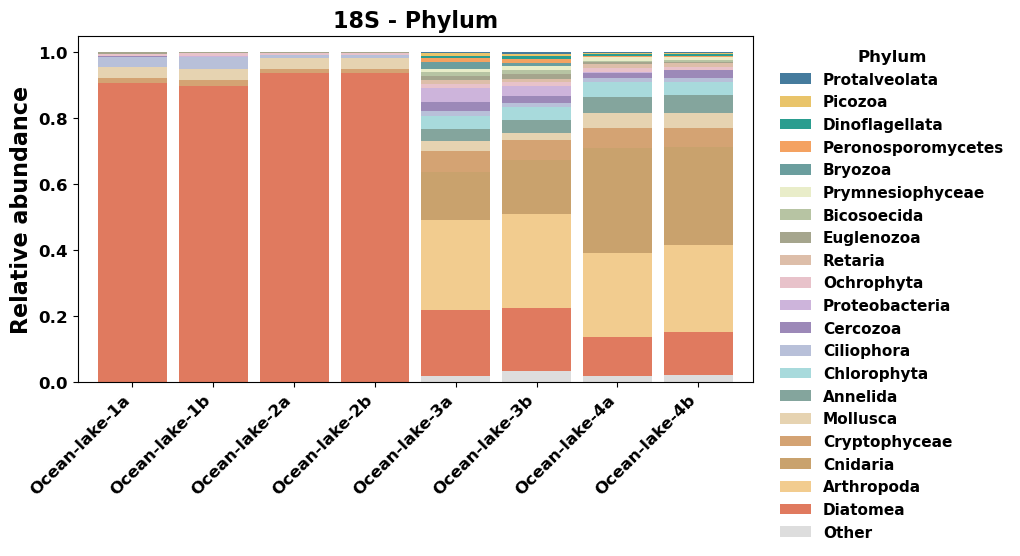

Done. PDFs saved to: /data10/xli/project/pama-seq/OL_18S_analysis/output/


In [57]:
# Configure global plotting styles for consistency and Illustrator compatibility
# Define output directory and plotting parameters (rank, top-N taxa, abundance threshold)
# Build relative abundance matrix (sample × taxon) from long-format data
# Rank taxa by overall abundance and select top taxa above threshold for visualization

import os
import matplotlib.pyplot as plt

# =========================
# Global style (safe on Linux/HPC)
# =========================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"


# =========================
# Parameters
# =========================
levels = ["Phylum"]
top_n = 20
min_abundance = 0.001

FS_TITLE = 16
FS_AXLABEL = 16
FS_TICK = 12
FS_LEGEND = 11
FS_LEGEND_TITLE = 12

# Expand the color palette to 21 distinct (non-repeating) colors.
extended_palette = [
    "#E07A5F", "#F2CC8F", "#C9A26D", "#D4A373", "#E6D3B1",
    "#84A59D", "#A8DADC", "#B8C0D9", "#9C89B8", "#CDB4DB",
    "#E8C2CA", "#DDBEA9", "#A5A58D", "#B7C4A3", "#E9EDC9",
    "#6B9E9E", "#F4A261", "#2A9D8F", "#E9C46A", "#457B9D",
    "#1D3557",
]


for rank in levels:

    # 1) Sum counts per Sample × Taxon
    df = (
        long_df
        .groupby(["SampleID", rank])["Count"]
        .sum()
        .reset_index()
    )

    # 2) Convert to relative abundance
    df["RelAbundance"] = df["Count"] / df.groupby("SampleID")["Count"].transform("sum")

    # 3) Wide table
    wide = df.pivot_table(
        index="SampleID",
        columns=rank,
        values="RelAbundance",
        fill_value=0
    )

    # 4) Order taxa by overall abundance
    tax_order = wide.sum(axis=0).sort_values(ascending=False)

    # 5) Top N + threshold
    keep = tax_order.head(top_n)
    keep = keep[keep >= min_abundance].index.tolist()
    keep = [k for k in keep if k != "Unassigned"]

    plot_df = wide[keep].copy()
    plot_df["Other"] = wide.drop(columns=keep, errors="ignore").sum(axis=1)

    ordered_cols = ["Other"] + (
        plot_df.drop(columns="Other").sum().sort_values(ascending=False).index.tolist()
    )
    plot_df = plot_df[ordered_cols]

    # 6) Colors: gray for "Other" + non-repeating color palette
    n_taxa = len(ordered_cols) - 1
    colors = ["#DDDDDD"] + extended_palette[:n_taxa]

    # 7) Plot
    fig, ax = plt.subplots(figsize=(10, 4.5))
    plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.85, color=colors)

    ax.set_ylabel("Relative abundance", fontsize=FS_AXLABEL)
    ax.set_xlabel("")
    ax.set_title(f"18S - {rank}", fontsize=FS_TITLE)

    ax.set_xticklabels(plot_df.index.tolist(), rotation=45, ha="right", fontsize=FS_TICK)
    ax.tick_params(axis="y", labelsize=FS_TICK)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1], labels[::-1],
        title=rank,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=FS_LEGEND,
        title_fontsize=FS_LEGEND_TITLE
    )

    plt.subplots_adjust(right=0.80)

    out_fp = os.path.join(out_dir, f"18S_{rank}_top{top_n}_thr{min_abundance}.pdf")
    plt.savefig(out_fp, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Done. PDFs saved to:", out_dir)

In [32]:
# Pivot long_df to wide format
wide_df = long_df.pivot_table(
    index=["Feature ID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"],
    columns="SampleID",
    values="Count",
    fill_value=0
)

# Flatten column names
wide_df.columns.name = None
wide_df = wide_df.reset_index()

# Drop rows where all sample counts are zero
tax_cols = ["Feature ID", "Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
sample_cols = [col for col in wide_df.columns if col not in tax_cols]
wide_df = wide_df[wide_df[sample_cols].sum(axis=1) > 0]

print(f"Shape: {wide_df.shape}")
wide_df.head()

Shape: (243, 16)


,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b
0,005b6594c36d41c0a68b5e7a3acff5c3,Eukaryota,MAST-12,MAST-12C,MAST-12C,MAST-12C,MAST-12C,Unassigned,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
1,007b10c0b915f30f555fb4e42ca63935,Eukaryota,Cercozoa,Imbricatea,Imbricatea,Thaumatomonadida,Gyromitus,Unassigned,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
2,015155602d9ce5798709655439c9c95c,Eukaryota,Cercozoa,Thecofilosea,Cryomonadida,Rhizaspididae,Rhogostoma,Unassigned,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
3,01af3e8fd35debf1e892d632c9cdb795,Eukaryota,Retaria,Acantharia,Symphyacanthida,Symphyacanthida,Amphibelone,Unassigned,0.0,0.0,0.0,0.0,62.0,71.0,220.0,229.0
4,02849e987055db30c9e0f9dd02a1ea33,Eukaryota,Prymnesiophyceae,Prymnesiophyceae,Prymnesiales,Prymnesiales,Chrysocampanula,Unassigned,0.0,0.0,0.0,0.0,22.0,50.0,90.0,55.0


In [58]:
wide_df.to_csv(out_dir+"wide_df_18s.csv", index=False)
print("Saved!")

Saved!


PCoA input shape: (8, 153)
Sample sums (should be close to 1.0):
SampleID
Ocean-lake-1a    1.0
Ocean-lake-1b    1.0
Ocean-lake-2a    1.0
Ocean-lake-2b    1.0
Ocean-lake-3a    1.0
Ocean-lake-3b    1.0
Ocean-lake-4a    1.0
Ocean-lake-4b    1.0
dtype: float64
        SampleID  Group Replicate ShortLabel
0  Ocean-lake-1a  River         a     18S-1a
1  Ocean-lake-1b  River         b     18S-1b
2  Ocean-lake-2a  River         a     18S-2a
3  Ocean-lake-2b  River         b     18S-2b
4  Ocean-lake-3a  Ocean         a     18S-3a
5  Ocean-lake-3b  Ocean         b     18S-3b
6  Ocean-lake-4a  Ocean         a     18S-4a
7  Ocean-lake-4b  Ocean         b     18S-4b

Bray-Curtis distance matrix:
SampleID       Ocean-lake-1a  Ocean-lake-1b  Ocean-lake-2a  Ocean-lake-2b  \
SampleID                                                                    
Ocean-lake-1a         0.0000         0.0091         0.0362         0.0375   
Ocean-lake-1b         0.0091         0.0000         0.0424         0.0439   


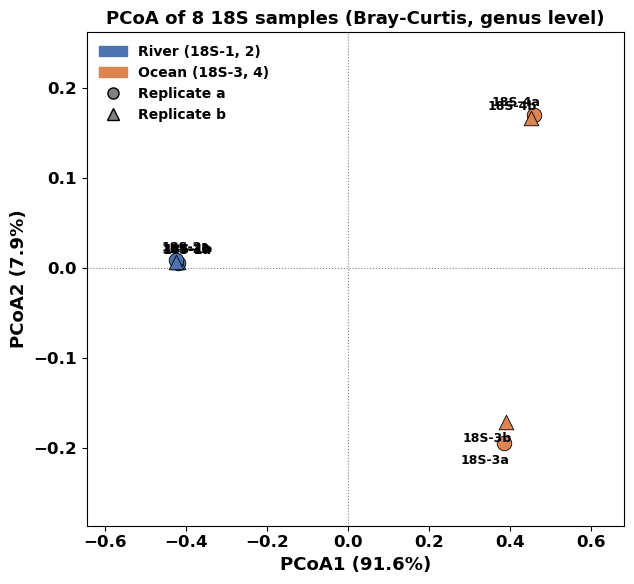

In [59]:
# Classical PCoA on all 8 18S samples
# Bray-Curtis distance + exact eigen decomposition
# Replicate a/b distinguished by marker shape, connected by dashed lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from matplotlib.lines import Line2D

# =========================
# 1. Prepare sample-by-genus matrix
# =========================
pcoa_input = genus_matrix_18s.T.copy()
print("PCoA input shape:", pcoa_input.shape)
print("Sample sums (should be close to 1.0):")
print(pcoa_input.sum(axis=1).round(4))

# =========================
# 2. Metadata
# =========================
metadata = pd.DataFrame({"SampleID": pcoa_input.index.tolist()})

metadata["Group"] = metadata["SampleID"].map({
    "Ocean-lake-1a": "River", "Ocean-lake-1b": "River",
    "Ocean-lake-2a": "River", "Ocean-lake-2b": "River",
    "Ocean-lake-3a": "Ocean", "Ocean-lake-3b": "Ocean",
    "Ocean-lake-4a": "Ocean", "Ocean-lake-4b": "Ocean",
})
metadata["Replicate"] = metadata["SampleID"].apply(
    lambda x: "a" if x.endswith("a") else "b"
)
metadata["ShortLabel"] = metadata["SampleID"].str.replace("Ocean-lake-", "18S-", regex=False)
print(metadata)

# =========================
# 3. Bray-Curtis distance matrix
# =========================
D = squareform(pdist(pcoa_input.values, metric="braycurtis"))
dist_df = pd.DataFrame(D, index=pcoa_input.index, columns=pcoa_input.index)
print("\nBray-Curtis distance matrix:")
print(dist_df.round(4))

# =========================
# 4. Classical PCoA (exact eigen decomposition)
# =========================
n = D.shape[0]

# Double-centering
H = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * H @ (D ** 2) @ H

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(B)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Keep only positive eigenvalues
positive = eigvals > 0
eigvals_pos = eigvals[positive]
eigvecs_pos = eigvecs[:, positive]

# PCoA coordinates (first two axes)
coords = eigvecs_pos[:, :2] * np.sqrt(eigvals_pos[:2])

# Explained variance
var_explained = eigvals_pos / eigvals_pos.sum()
pc1_pct = var_explained[0] * 100
pc2_pct = var_explained[1] * 100
print(f"\nPCoA1: {pc1_pct:.1f}%")
print(f"PCoA2: {pc2_pct:.1f}%")

# =========================
# 5. Build coordinate DataFrame
# =========================
pcoa_df = pd.DataFrame(
    coords, columns=["PCoA1", "PCoA2"],
    index=pcoa_input.index
).reset_index().rename(columns={"index": "SampleID"})
pcoa_df = pcoa_df.merge(metadata, on="SampleID", how="left")
print(pcoa_df)

# =========================
# 6. Plot
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "font.size": 12,
})

group_colors  = {"River": "#4C72B0", "Ocean": "#DD8452"}
rep_markers   = {"a": "o", "b": "^"}   # circle = replicate a, triangle = replicate b

# --- compute axis limits with padding BEFORE plotting ---
x_pad = (pcoa_df["PCoA1"].max() - pcoa_df["PCoA1"].min()) * 0.25
y_pad = (pcoa_df["PCoA2"].max() - pcoa_df["PCoA2"].min()) * 0.25
xlim = (pcoa_df["PCoA1"].min() - x_pad, pcoa_df["PCoA1"].max() + x_pad)
ylim = (pcoa_df["PCoA2"].min() - y_pad, pcoa_df["PCoA2"].max() + y_pad)

fig, ax = plt.subplots(figsize=(6.5, 6.0))

# -- scatter points --
for _, row in pcoa_df.iterrows():
    ax.scatter(
        row["PCoA1"], row["PCoA2"],
        s=110,
        color=group_colors[row["Group"]],
        marker=rep_markers[row["Replicate"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

# -- dashed lines connecting replicate a/b pairs --
replicate_pairs = [
    ("Ocean-lake-1a", "Ocean-lake-1b"),
    ("Ocean-lake-2a", "Ocean-lake-2b"),
    ("Ocean-lake-3a", "Ocean-lake-3b"),
    ("Ocean-lake-4a", "Ocean-lake-4b"),
]
for sa, sb in replicate_pairs:
    xa, ya = pcoa_df.loc[pcoa_df["SampleID"] == sa, ["PCoA1", "PCoA2"]].values[0]
    xb, yb = pcoa_df.loc[pcoa_df["SampleID"] == sb, ["PCoA1", "PCoA2"]].values[0]
    ax.plot([xa, xb], [ya, yb], color="gray", lw=0.9, ls="--", zorder=1)

# -- sample labels: smart offset to avoid going outside plot --
x_range = xlim[1] - xlim[0]
y_range = ylim[1] - ylim[0]
x_mid   = (xlim[0] + xlim[1]) / 2
y_mid   = (ylim[0] + ylim[1]) / 2

for _, row in pcoa_df.iterrows():
    dx = -0.035 * x_range if row["PCoA1"] > x_mid else 0.018 * x_range
    dy =  0.025 * y_range if row["PCoA2"] > y_mid else -0.035 * y_range
    ax.text(
        row["PCoA1"] + dx,
        row["PCoA2"] + dy,
        row["ShortLabel"],
        fontsize=9,
        ha="center", va="center",
    )

# -- reference lines --
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(f"PCoA1 ({pc1_pct:.1f}%)", fontsize=13)
ax.set_ylabel(f"PCoA2 ({pc2_pct:.1f}%)", fontsize=13)
ax.set_title("PCoA of 8 18S samples (Bray-Curtis, genus level)", fontsize=13)

# -- legend --
legend_handles = [
    mpatches.Patch(color=group_colors["River"], label="River (18S-1, 2)"),
    mpatches.Patch(color=group_colors["Ocean"], label="Ocean (18S-3, 4)"),
    Line2D([0], [0], marker="o", color="gray", label="Replicate a",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
    Line2D([0], [0], marker="^", color="gray", label="Replicate b",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10, loc="best")

plt.tight_layout()
plt.savefig(out_dir + "18S_PCoA_braycurtis_final.pdf", bbox_inches="tight")
plt.show()

# =========================
# 7. Export tables
# =========================
dist_df.to_csv(out_dir + "18s_pcoa_braycurtis_distance_matrix_8samples.csv")
pcoa_df.to_csv(out_dir + "18s_pcoa_coordinates_8samples.csv", index=False)

In [60]:
out_dir

'/data10/xli/project/pama-seq/OL_18S_analysis/output/'

In [61]:
genus_matrix_18s.to_csv(out_dir + "18S_genus_matrix.csv")
plot_df.to_csv(out_dir + "18S_phylum_relative_abundance_top20.csv")